In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")

df = sns.load_dataset('titanic')
print("Data loaded successfully!")

Data loaded successfully!


In [4]:
# 1. Look at the first 5 rows
print(df.head())

# 2. Check data types and see how many rows are missing data
print(df.info())

# 3. Count the exact missing values per column
print(df.isnull().sum())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

In [5]:
# Fix Age: Fill the missing ages with the median age of all passengers
df['age'] = df['age'].fillna(df['age'].median())

# Fix Deck: It's missing too much data to rescue, so we drop it
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

# Fix Embarked: Fill the 2 missing rows with the most common port ('S')
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Verify that everything is clean now
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [6]:
# Fix Age: Fill the missing ages with the median age of all passengers
df['age'] = df['age'].fillna(df['age'].median())

# Fix Deck: It's missing too much data to rescue, so we drop it
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

# Fix Embarked: Fill the 2 missing rows with the most common port ('S')
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Verify that everything is clean now
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


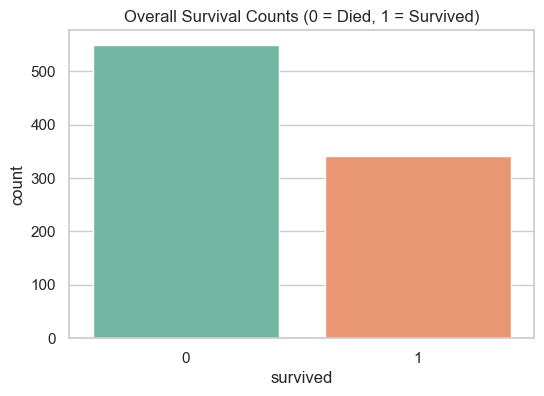

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='survived', hue='survived', palette='Set2', legend=False)
plt.title('Overall Survival Counts (0 = Died, 1 = Survived)')
plt.show()

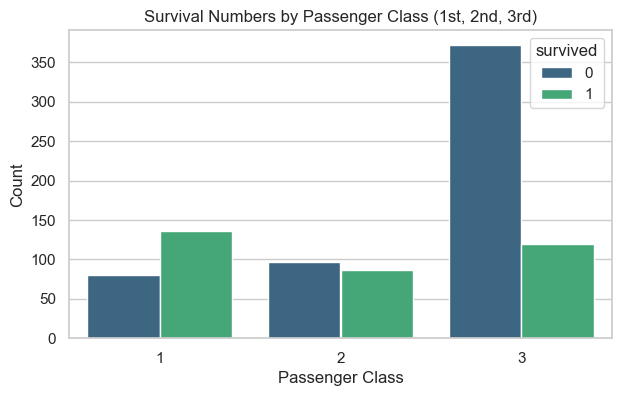

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='pclass', hue='survived', palette='viridis')
plt.title('Survival Numbers by Passenger Class (1st, 2nd, 3rd)')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

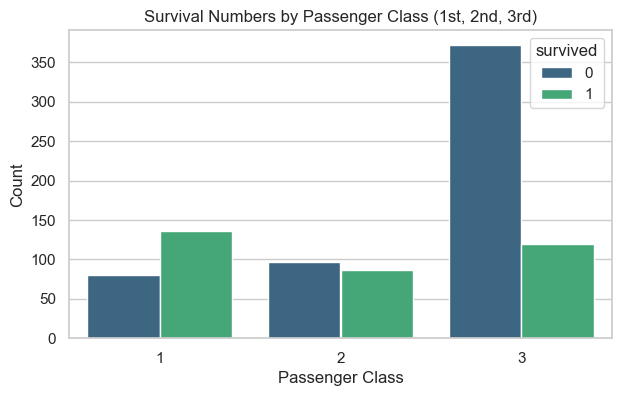

In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='pclass', hue='survived', palette='viridis')
plt.title('Survival Numbers by Passenger Class (1st, 2nd, 3rd)')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

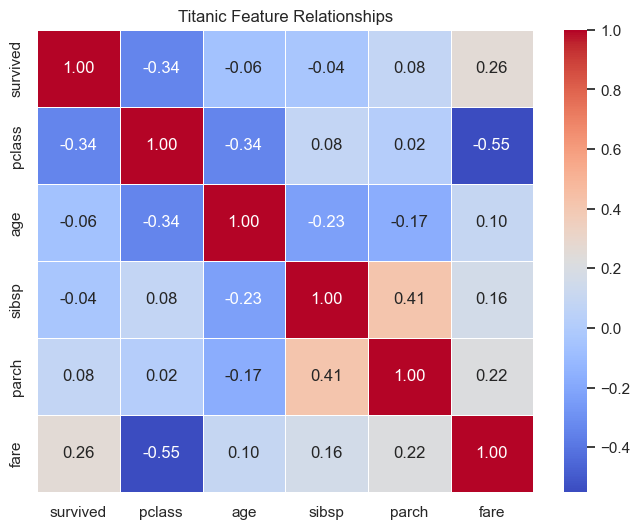

In [10]:
plt.figure(figsize=(8, 6))

# Select only the columns containing numbers
numeric_df = df.select_dtypes(include=[np.number])

# Generate a correlation heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Titanic Feature Relationships')
plt.show()